# SmartCart
## E-commerce customer segmentation system

In [138]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [80]:
df = pd.read_csv("smartcart_customers.csv")

## Understanding the Data:

In [81]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [82]:
df.shape

(2240, 22)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [84]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [85]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [86]:
df.duplicated().sum()

np.int64(0)

## Data Preprocessing:

### 1. Handle missing values:

In [87]:
df["Income"] = df["Income"].fillna(df["Income"].median())

### 2. Feature Engineering:

In [88]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [89]:
# Age ----from the year_birth feature

df["Age"] = 2026 - df["Year_Birth"]

In [90]:
# Customer_Tenure (customer kitne time se hai) ------------- from Customer Joinning dates(Dt_Customer)

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure"] = (reference_date - df["Dt_Customer"]).dt.days

In [91]:
# Spendings of customers on different products is in one Total Spending column

df["Total_Spending"] = df[["MntWines", "MntFruits", "MntMeatProducts",
                           "MntFishProducts", "MntSweetProducts",
                           "MntGoldProds"]].sum(axis=1)

In [92]:
# make one column for teen and kidhome

df["Total_Childerns"] = df["Kidhome"] + df["Teenhome"]

In [93]:
# Education ---- divide them into only Graduate , Undergraduate and PostGraduate
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [94]:
df["Education"] = df["Education"].replace({
    "Graduation" : "Graduate" , 
    "PhD" : "Postgraduate", "Master" : "Postgraduate", 
    "2n Cycle" : "Undergraduate", "Basic" : "Undergraduate"
})

In [95]:
# Marital_Status ------ divied them into single or living together 

df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [96]:
df["Living_Status"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" : "Partner",
    "Divorced" : "Alone", "Widow" : "Alone", "Single" : "Alone",
    "Absurd" : "Alone", "YOLO" : "Alone"
})

In [97]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,Total_Spending,Total_Childerns,Living_Status
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


### 3. Drop Unnecessary Columns:

In [98]:
cols = ["ID" , "Year_Birth" , "Marital_Status" , "Kidhome" , "Teenhome" , "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [99]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,Total_Spending,Total_Childerns,Living_Status
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [100]:
df_cleaned.shape

(2240, 15)

### 4. Outliers: 

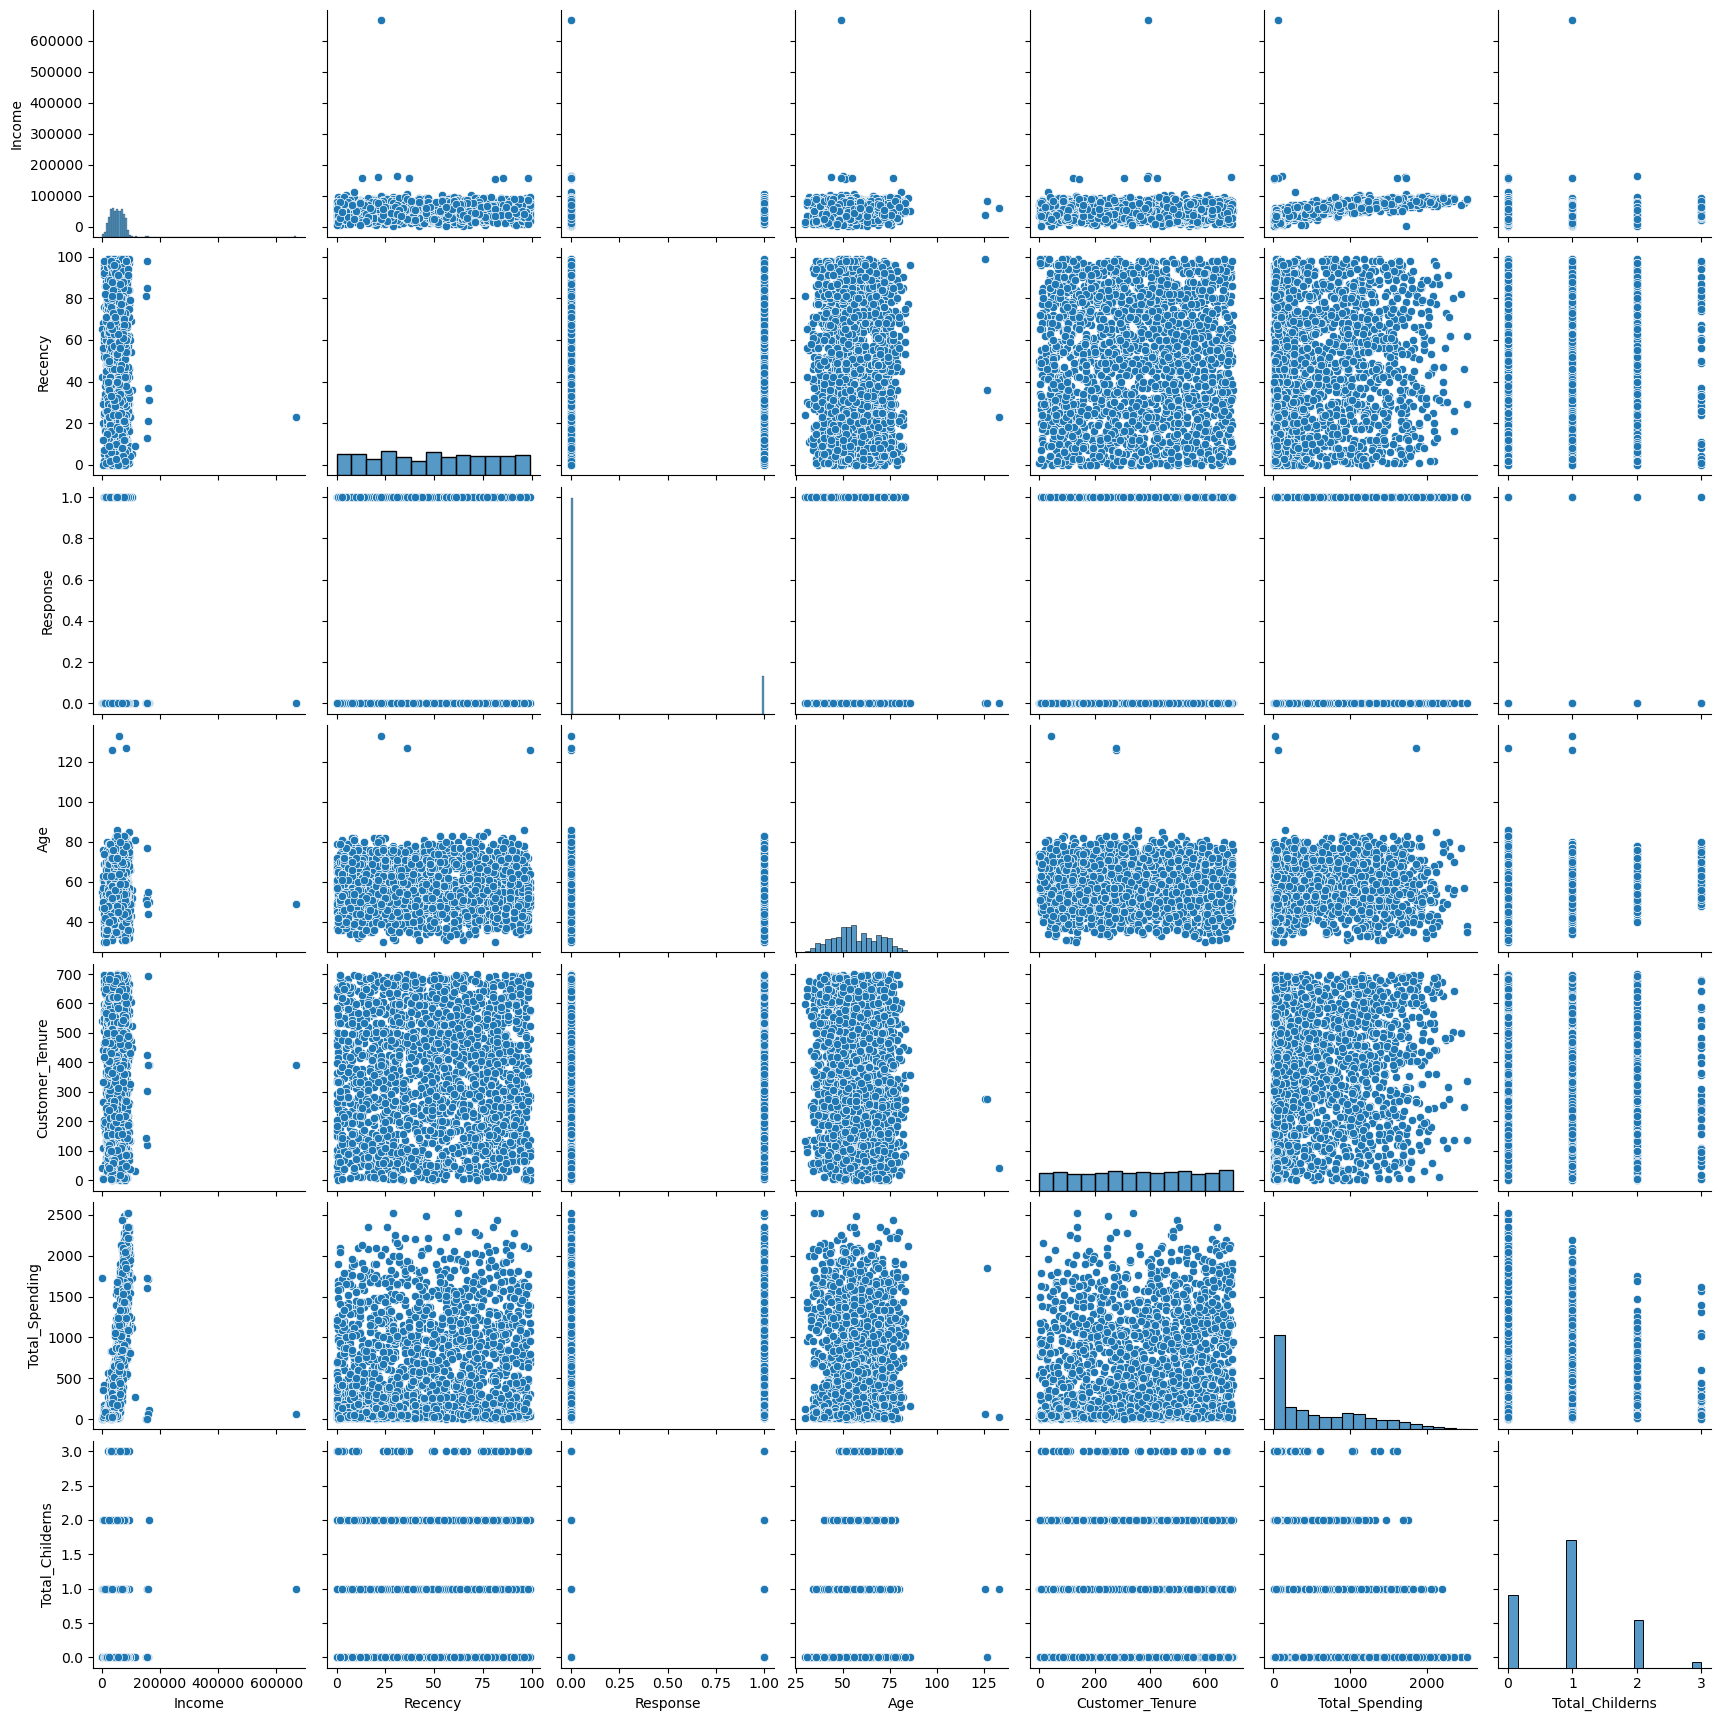

In [101]:
# here we will visualize by making pairplot that is there are outliers to be seen easily:

cols = ["Income" , "Recency" , "Response" , "Age" , "Customer_Tenure" , "Total_Spending", "Total_Childerns"]

sns.pairplot(df_cleaned[cols])

In [102]:
# 2 outliers detected ---- Age and income 
print("Data size with the outliers in it : " , len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("Data size without the outliers in it : " , len(df_cleaned))


Data size with the outliers in it :  2240
Data size without the outliers in it :  2236


## Heatmap:

In [103]:
corr = df_cleaned.corr(numeric_only=True)
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,Total_Spending,Total_Childerns
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


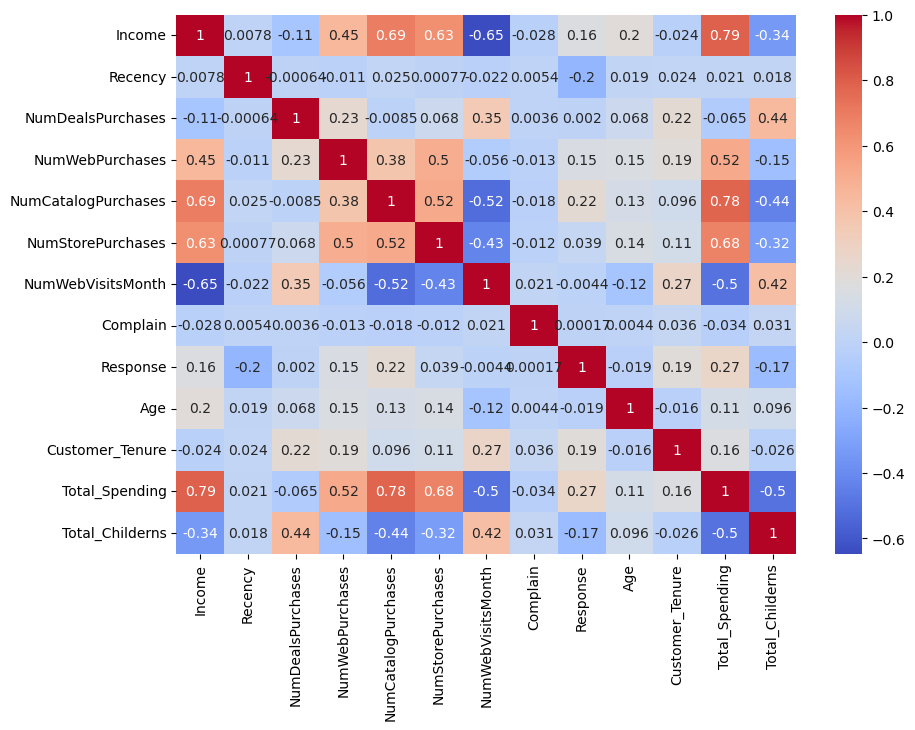

In [104]:
plt.figure(figsize=(10 , 7))

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Encoding:

In [105]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,Total_Spending,Total_Childerns,Living_Status
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [128]:
df_cleaned.shape

(2236, 15)

In [129]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_Status"]

encoded = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(
    encoded.toarray(),
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_cleaned.index
)

In [130]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols) , enc_df], axis=1)

In [131]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,Total_Spending,Total_Childerns,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [132]:
df_encoded.shape

(2236, 18)

In [133]:
df_encoded.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure', 'Total_Spending',
       'Total_Childerns', 'Education_Graduate', 'Education_Postgraduate',
       'Education_Undergraduate', 'Living_Status_Alone',
       'Living_Status_Partner'],
      dtype='object')

In [135]:
X = df_encoded

## Scaling Data:

In [136]:
scalar = StandardScaler()

X_scaled = scalar.fit_transform(X)

In [137]:
X_scaled.shape

(2236, 18)

## Visualize:

In [139]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

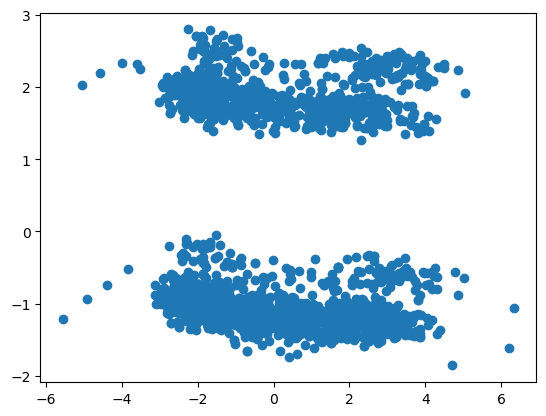

In [140]:
plt.scatter(X_pca[:, 0] , X_pca[:, 1])

In [141]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [142]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D Projection')

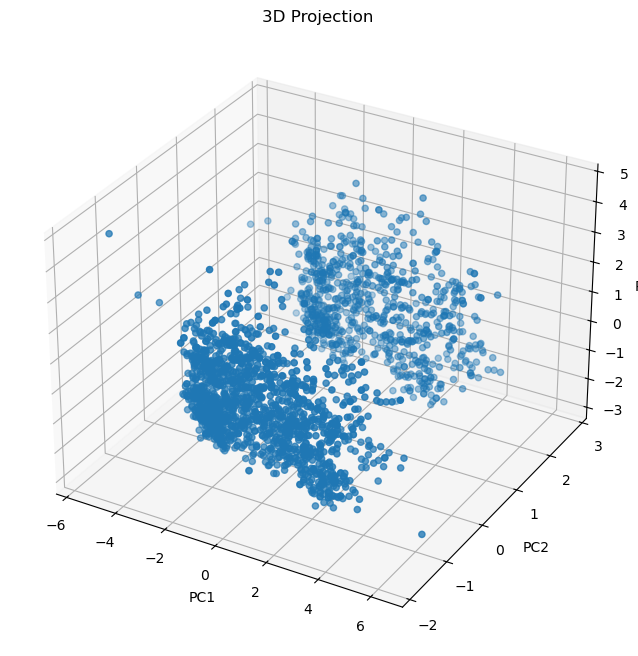

In [148]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2]
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D Projection")


## Analyze K-values:

### 1- Elbow Method


In [ ]:
from kneed import KneeLocator, DataGenerator
from sklearn.cluster import KMeans


wcss = [] 
for k in range(1,11):
    kmeans = KMeans(n_clusters=k , random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [157]:
knee = KneeLocator(range(1,11) , wcss , curve="convex" , direction="decreasing")
print("Optimal k = " , knee.knee)

Optimal k =  4


Text(0, 0.5, 'WCSS')

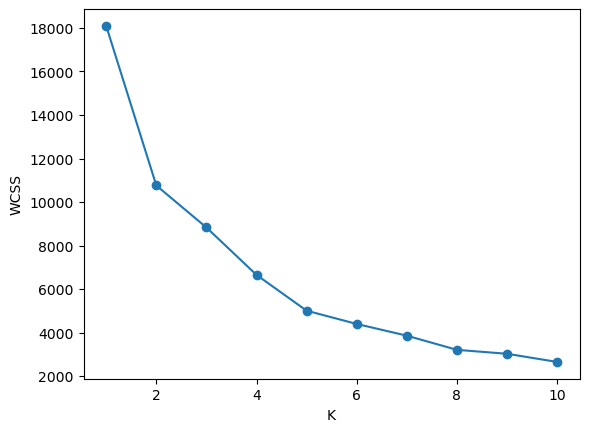

In [158]:
# plot

plt.plot(range(1,11) , wcss , marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

### 2- Silhouette Score


In [ ]:
from sklearn.metrics import silhouette_score

scores = [] 
for k in range(2,11):
    kmeans = KMeans(n_clusters=k , random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)

    scores.append(score)

Text(0, 0.5, 'Silhouette Score')

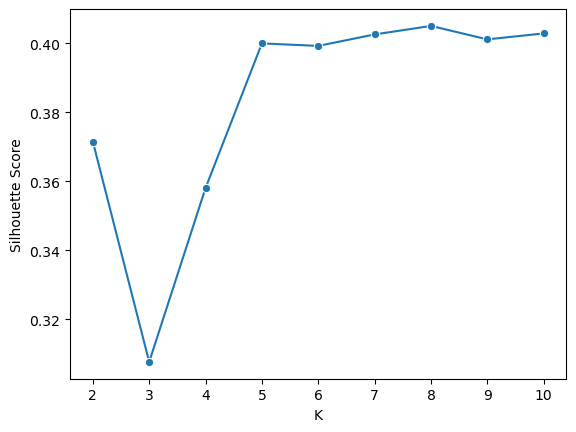

In [163]:
sns.lineplot(x = range(2,11) , y = scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

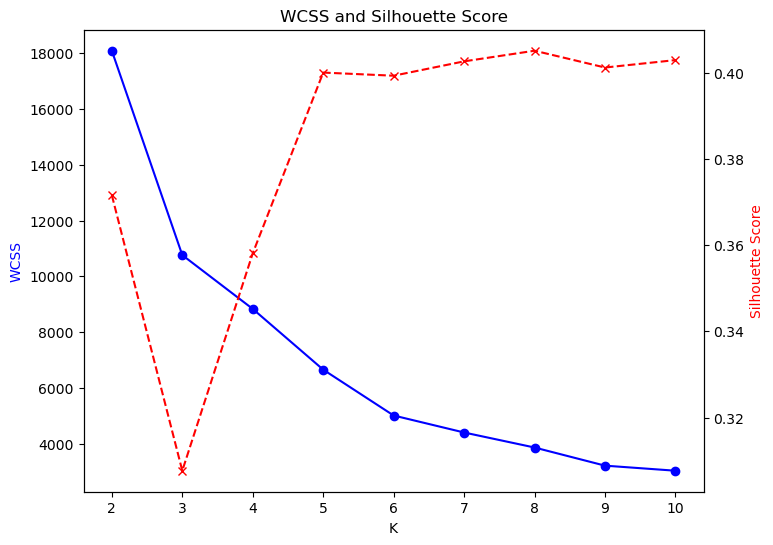

In [181]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

# WCSS
ax1.plot(
    k_range,
    wcss[:len(k_range)],
    marker="o",
    color="blue"
)
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS", color="blue")

# Silhouette Score
ax2 = ax1.twinx()

ax2.plot(
    k_range,
    scores[:len(k_range)],
    marker="x",
    color="red",
    linestyle="--"
)
ax2.set_ylabel("Silhouette Score", color="red")

plt.title("WCSS and Silhouette Score")
plt.show()

# Clustering: 

## Using K-Means

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42) 

kMeans_labels = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3D Projection')

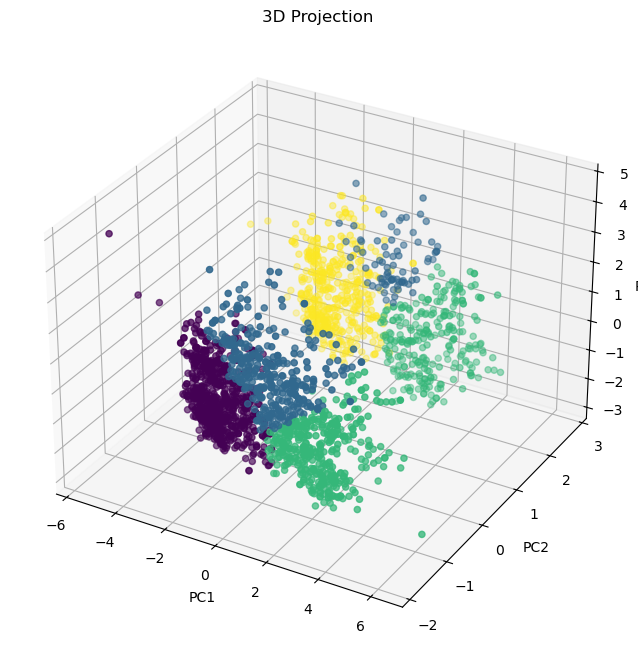

In [185]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c= kMeans_labels
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D Projection")

## Using Agglomerative Clustering

In [187]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_pca)

Text(0.5, 0.92, '3D Projection')

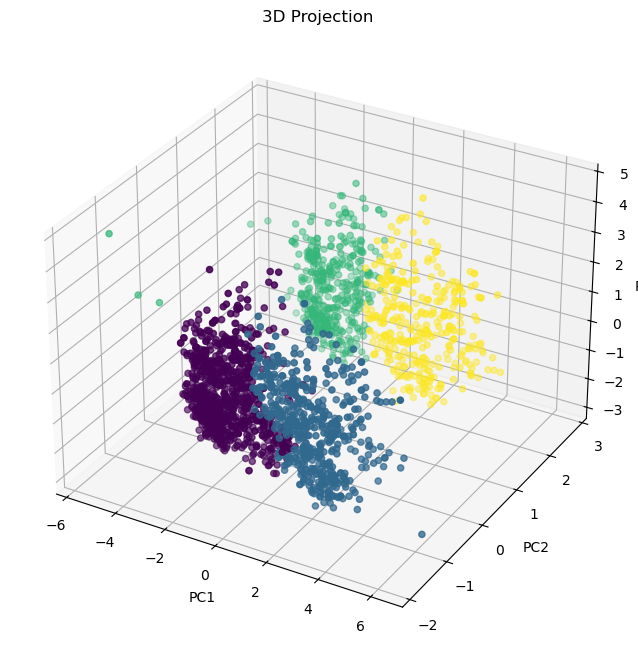

In [188]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c= agg_labels
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D Projection")

# Characterization of Clusters

In [193]:
X["cluster"] = agg_labels

In [194]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure,Total_Spending,Total_Childerns,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

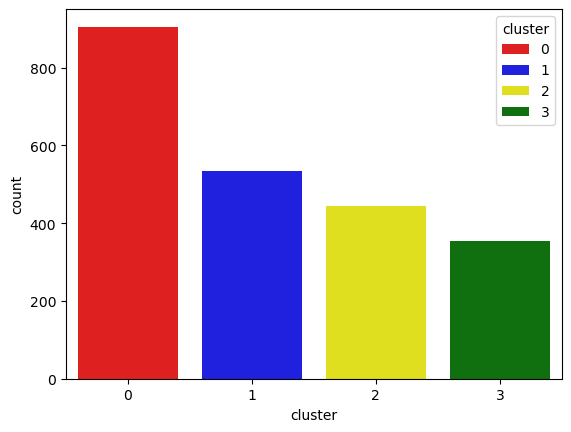

In [195]:
pal = ["red" , "blue" , "yellow" , "green"]

sns.countplot(x=X["cluster"] , palette=pal , hue= X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

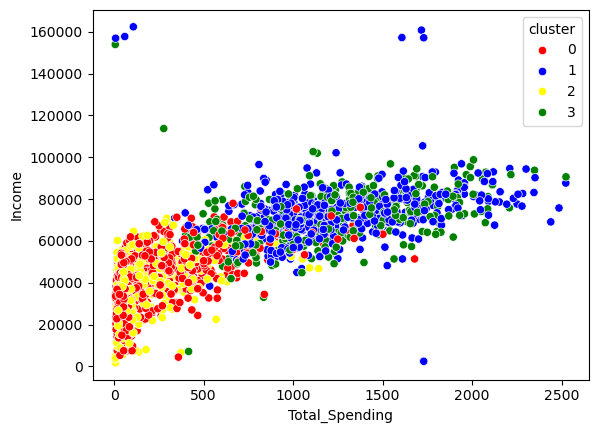

In [197]:
# income and total spending 

sns.scatterplot(x = X["Total_Spending"] , y = X["Income"] , hue = X["cluster"] , palette=pal)

# Cluster Summary:

In [198]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure  Total_Spending  \
cluster              